In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix, roc_curve, precision_recall_curve
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_raw = pd.read_excel if False else pd.read_csv("../data/raw/diabetic_data.csv")
df = df_raw.copy()
df.shape

(101766, 50)

In [3]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df = df.replace('?', np.nan)
df.isna().mean().sort_values(ascending=False).head(10)

weight               0.968585
max_glu_serum        0.947468
A1Cresult            0.832773
medical_specialty    0.490822
payer_code           0.395574
race                 0.022336
diag_3               0.013983
diag_2               0.003518
diag_1               0.000206
patient_nbr          0.000000
dtype: float64

In [5]:
df = df.drop(columns=['weight', 'payer_code', 'medical_specialty'])
df.shape

(101766, 47)

In [6]:
death_hospice_codes = [11, 19, 20, 21, 13, 14]
print(df['discharge_disposition_id'].isin(death_hospice_codes).sum(), "rows to remove")
df = df[~df['discharge_disposition_id'].isin(death_hospice_codes)]
df.shape

2423 rows to remove


(99343, 47)

In [7]:
df = df.dropna(subset=['race'])
df.shape

(97109, 47)

In [8]:
df['max_glu_serum'] = df['max_glu_serum'].fillna('Not Tested')
df['A1Cresult'] = df['A1Cresult'].fillna('Not Tested')

In [9]:
print("total rows:", df.shape[0])
print("unique patients:", df['patient_nbr'].nunique())
print("duplicate patient rows:", df['patient_nbr'].duplicated().sum())

total rows: 97109
unique patients: 68167
duplicate patient rows: 28942


In [10]:
df['readmitted'].value_counts()

readmitted
NO     51019
>30    34964
<30    11126
Name: count, dtype: int64

In [11]:
df['target'] = (df['readmitted'] == '<30').astype(int)
df['target'].value_counts(normalize=True)

target
0    0.885428
1    0.114572
Name: proportion, dtype: float64

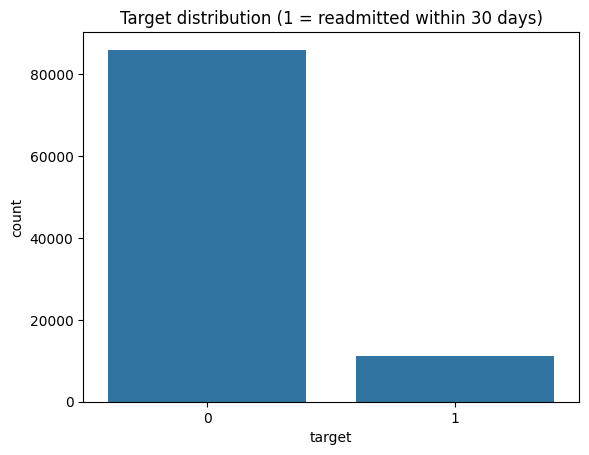

In [12]:
sns.countplot(x='target', data=df)
plt.title('Target distribution (1 = readmitted within 30 days)')
plt.show()

In [13]:
age_order = sorted(df['age'].unique())
age_map = {age: i for i, age in enumerate(age_order)}
df['age_ordinal'] = df['age'].map(age_map)
age_map

{'[0-10)': 0,
 '[10-20)': 1,
 '[20-30)': 2,
 '[30-40)': 3,
 '[40-50)': 4,
 '[50-60)': 5,
 '[60-70)': 6,
 '[70-80)': 7,
 '[80-90)': 8,
 '[90-100)': 9}

In [14]:
def bucket_diag(code):
    if pd.isna(code):
        return 'Missing'
    try:
        c = float(code)
    except:
        return 'Other'
    if 390 <= c <= 459 or c == 785:
        return 'Circulatory'
    elif 460 <= c <= 519 or c == 786:
        return 'Respiratory'
    elif 520 <= c <= 579 or c == 787:
        return 'Digestive'
    elif int(c) == 250:
        return 'Diabetes'
    elif 800 <= c <= 999:
        return 'Injury'
    elif 710 <= c <= 739:
        return 'Musculoskeletal'
    elif 580 <= c <= 629 or c == 788:
        return 'Genitourinary'
    elif 140 <= c <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col + '_group'] = df[col].apply(bucket_diag)

df['diag_1_group'].value_counts()

diag_1_group
Circulatory        29012
Other              17354
Respiratory        13626
Digestive           9155
Diabetes            8472
Injury              6702
Genitourinary       4912
Musculoskeletal     4804
Neoplasms           3054
Missing               18
Name: count, dtype: int64

In [15]:
drop_cols = ['encounter_id', 'readmitted', 'diag_1', 'diag_2', 'diag_3', 'age']
model_df = df.drop(columns=drop_cols)

cat_cols = model_df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'patient_nbr']
len(cat_cols)

32

In [16]:
model_df_enc = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)
model_df_enc.columns = [c.replace('[','').replace(']','').replace('<','lt').replace('>','gt')
                         .replace(',','_').replace(' ','_').replace('(','').replace(')','').replace('-','_')
                         for c in model_df_enc.columns]

y = model_df_enc['target']
groups = model_df_enc['patient_nbr']
X = model_df_enc.drop(columns=['target', 'patient_nbr'])
X.shape

(97109, 100)

In [17]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# sanity check, this should be an empty set
overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print("patient overlap between train/test:", len(overlap))
print(X_train.shape, X_test.shape)

patient overlap between train/test: 0
(77526, 100) (19583, 100)


In [18]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_s, y_train)
proba_lr = logreg.predict_proba(X_test_s)[:, 1]

print("LogReg ROC-AUC:", roc_auc_score(y_test, proba_lr))
print("LogReg PR-AUC:", average_precision_score(y_test, proba_lr))

LogReg ROC-AUC: 0.6450061175325386
LogReg PR-AUC: 0.20751246950090196


In [19]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGB ROC-AUC:", roc_auc_score(y_test, proba_xgb))
print("XGB PR-AUC:", average_precision_score(y_test, proba_xgb))

scale_pos_weight: 7.730405405405405
XGB ROC-AUC: 0.661507096425061
XGB PR-AUC: 0.21730769225319319


In [20]:
preds_xgb = (proba_xgb >= 0.5).astype(int)
print(classification_report(y_test, preds_xgb))

              precision    recall  f1-score   support

           0       0.92      0.63      0.75     17337
           1       0.17      0.60      0.27      2246

    accuracy                           0.62     19583
   macro avg       0.55      0.61      0.51     19583
weighted avg       0.84      0.62      0.69     19583



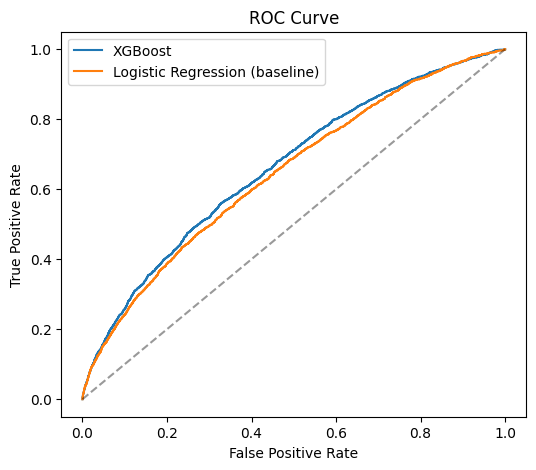

In [21]:
fpr, tpr, _ = roc_curve(y_test, proba_xgb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='XGBoost')
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression (baseline)')
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

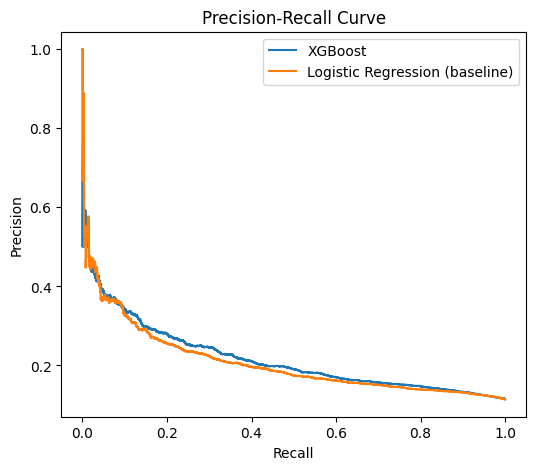

In [22]:
prec, rec, _ = precision_recall_curve(y_test, proba_xgb)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, proba_lr)

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label='XGBoost')
plt.plot(rec_lr, prec_lr, label='Logistic Regression (baseline)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [23]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap_values.shape

(19583, 100)

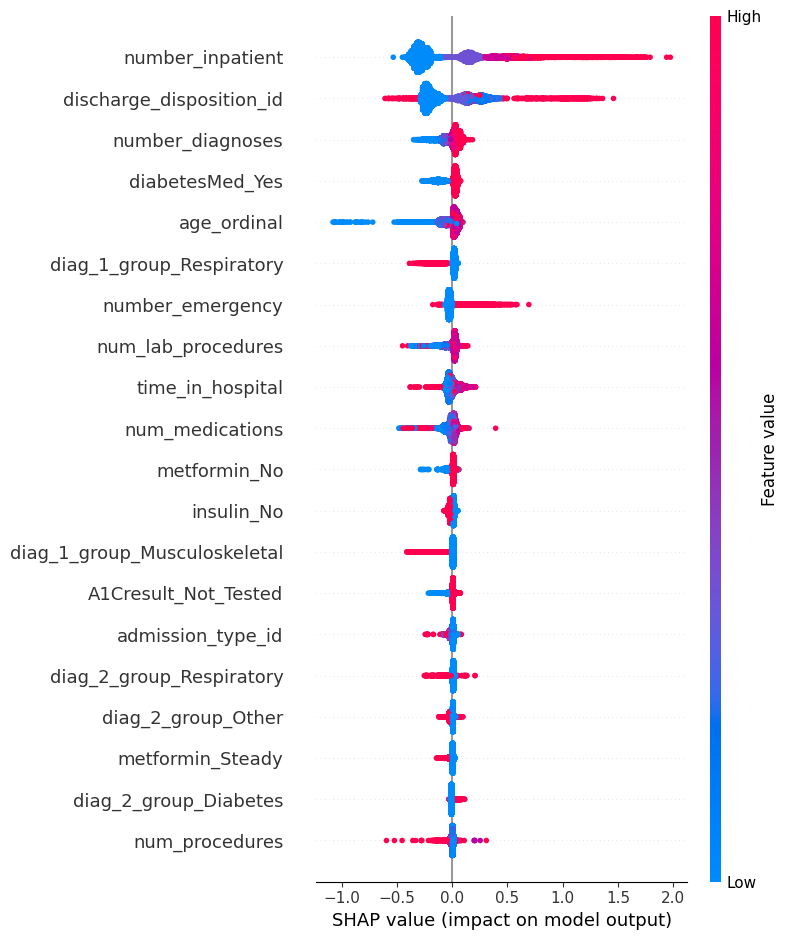

In [24]:
shap.summary_plot(shap_values, X_test, show=False)
plt.show()

In [25]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features = pd.Series(mean_abs_shap, index=X_test.columns).sort_values(ascending=False)
top_features.head(15)

number_inpatient                0.312864
discharge_disposition_id        0.216964
number_diagnoses                0.055772
diabetesMed_Yes                 0.052413
age_ordinal                     0.048532
diag_1_group_Respiratory        0.038110
number_emergency                0.037976
num_lab_procedures              0.037017
time_in_hospital                0.036539
num_medications                 0.030460
metformin_No                    0.019338
insulin_No                      0.018349
diag_1_group_Musculoskeletal    0.017344
A1Cresult_Not_Tested            0.015308
admission_type_id               0.014699
dtype: float32

In [26]:
sensitive_cols = [c for c in X_test.columns if c.startswith('race_') or c.startswith('gender_')]
ranks = top_features.rank(ascending=False)
print(top_features[sensitive_cols])
print(ranks[sensitive_cols])

race_Asian                0.000018
race_Caucasian            0.003689
race_Hispanic             0.000841
race_Other                0.000066
gender_Male               0.009463
gender_Unknown/Invalid    0.000000
dtype: float32
race_Asian                79.0
race_Caucasian            33.0
race_Hispanic             52.0
race_Other                74.0
gender_Male               21.0
gender_Unknown/Invalid    90.0
dtype: float64


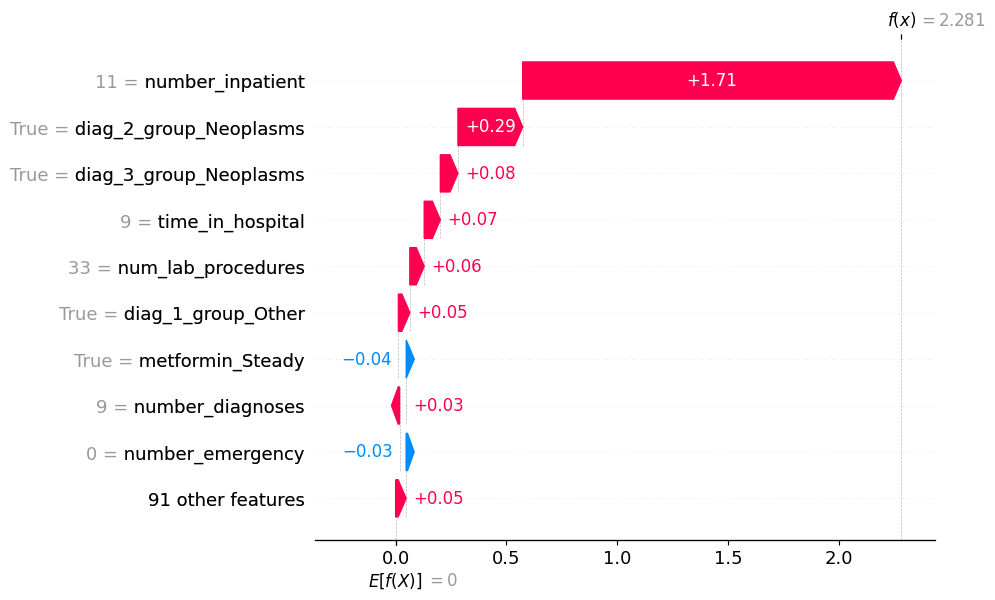

In [27]:
high_risk_idx = np.argsort(proba_xgb)[-3:]
i = high_risk_idx[-1]

shap.plots.waterfall(shap.Explanation(
    values=shap_values[i],
    base_values=explainer.expected_value,
    data=X_test.iloc[i],
    feature_names=X_test.columns.tolist()
))

In [28]:
results = X_test.copy()
results['actual'] = y_test.values
results['predicted_proba'] = proba_xgb
results.to_csv('../data/processed/test_predictions.csv', index=False)
results.head()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,diag_3_group_Digestive,diag_3_group_Genitourinary,diag_3_group_Injury,diag_3_group_Missing,diag_3_group_Musculoskeletal,diag_3_group_Neoplasms,diag_3_group_Other,diag_3_group_Respiratory,actual,predicted_proba
4,1,1,7,1,51,0,8,0,0,0,...,False,False,False,False,False,False,False,False,0,0.427124
13,1,6,7,10,55,1,31,0,0,0,...,False,False,False,False,False,False,False,False,0,0.543049
14,3,1,2,1,49,5,2,0,0,0,...,False,True,False,False,False,False,False,False,0,0.319583
23,2,6,1,11,42,2,19,0,0,0,...,False,False,False,False,False,False,True,False,0,0.430200
24,3,1,2,3,19,4,18,0,0,0,...,False,False,False,False,False,False,False,False,0,0.331671
